# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  

**`Student Name`:**  Eshan Srirambhatla

**`Roll Number`:**  U20230126

**`GitHub Branch`:** firstname_U20230126

# Imports and Setup

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

# Set random seed for reproducibility
np.random.seed(42)

# Load Datasets

In [20]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [21]:
train_users.dropna(inplace=True)
test_users.dropna(inplace=True)
news_df.dropna(inplace=True)

In [22]:
features = ['age', 'income', 'clicks', 'purchase_amount']
X_train = train_users[features].copy()
y_train = train_users['label'].copy()

X_test = test_users[features].copy()
y_test = test_users['label'].copy()

print("Training Features Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Test Features Shape:", X_test.shape)
print("Test Labels Shape:", y_test.shape)

# Encode target labels (user1, user2, user3 -> 0, 1, 2)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("\nLabel Encoding Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {i}")

print(f"\nEncoded training labels (first 10): {y_train_encoded[:10]}")
print(f"Original training labels (first 10): {y_train[:10].values}")

Training Features Shape: (2000, 4)
Training Labels Shape: (2000,)
Test Features Shape: (2000, 4)
Test Labels Shape: (2000,)

Label Encoding Mapping:
  user1 -> 0
  user2 -> 1
  user3 -> 2

Encoded training labels (first 10): [2 2 1 2 0 1 2 2 0 1]
Original training labels (first 10): <StringArray>
['user3', 'user3', 'user2', 'user3', 'user1', 'user2', 'user3', 'user3',
 'user1', 'user2']
Length: 10, dtype: str


In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features)

## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


LOGISTIC REGRESSION RESULTS
Training Accuracy: 0.3680 (36.80%)
Test Accuracy: 0.3295 (32.95%)

Classification Report (Test Set):
              precision    recall  f1-score   support

       user1       0.35      0.50      0.41       672
       user2       0.32      0.36      0.34       679
       user3       0.29      0.13      0.18       649

    accuracy                           0.33      2000
   macro avg       0.32      0.33      0.31      2000
weighted avg       0.32      0.33      0.31      2000



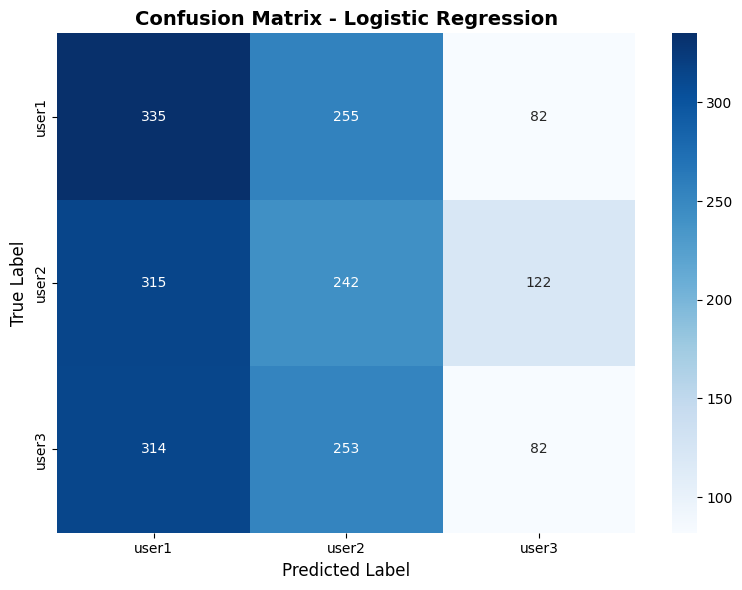

In [24]:
# Train Logistic Regression model
lr_model = LogisticRegression(random_state=42, max_iter=10000)
lr_model.fit(X_train_scaled, y_train_encoded)

# Make predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Calculate accuracy
train_accuracy_lr = accuracy_score(y_train_encoded, y_train_pred_lr)
test_accuracy_lr = accuracy_score(y_test_encoded, y_test_pred_lr)

print("="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)
print(f"Training Accuracy: {train_accuracy_lr:.4f} ({train_accuracy_lr*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy_lr:.4f} ({test_accuracy_lr*100:.2f}%)")

print("\nClassification Report (Test Set):")
print(classification_report(y_test_encoded, y_test_pred_lr, 
                          target_names=label_encoder.classes_))

# Confusion Matrix
cm_lr = confusion_matrix(y_test_encoded, y_test_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

DECISION TREE RESULTS
Training Accuracy: 0.4250 (42.50%)
Test Accuracy: 0.3305 (33.05%)

Classification Report (Test Set):
              precision    recall  f1-score   support

       user1       0.32      0.26      0.29       672
       user2       0.34      0.51      0.41       679
       user3       0.33      0.21      0.26       649

    accuracy                           0.33      2000
   macro avg       0.33      0.33      0.32      2000
weighted avg       0.33      0.33      0.32      2000


Feature Importance:
           feature  importance
3  purchase_amount    0.397916
1           income    0.224322
0              age    0.209440
2           clicks    0.168322


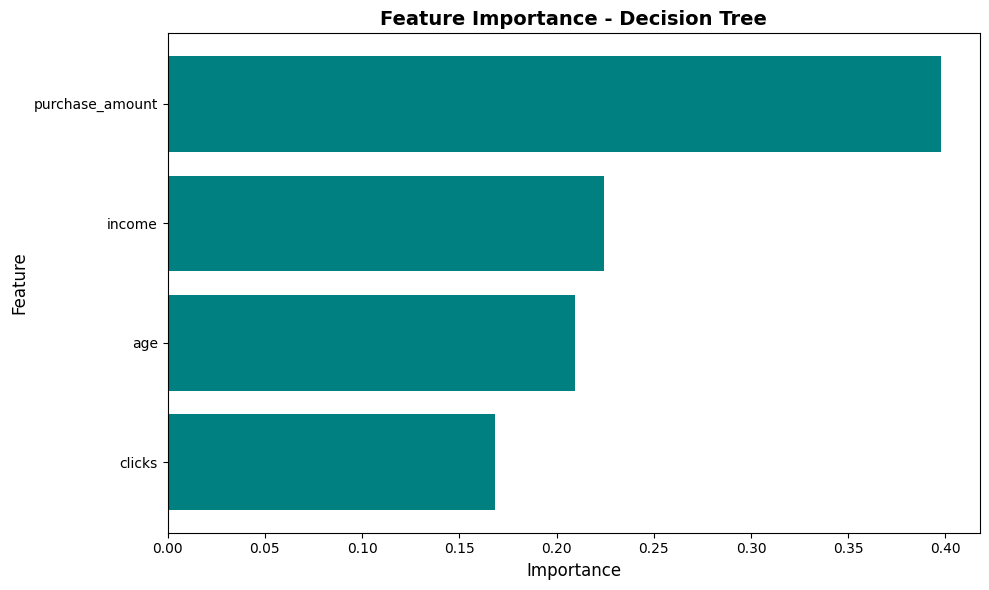

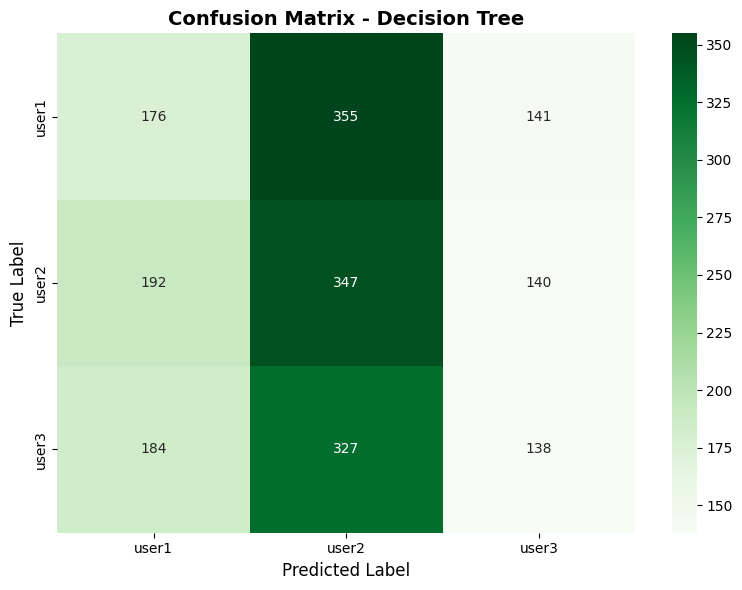

In [25]:
# Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train_encoded)

# Make predictions
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

# Calculate accuracy
train_accuracy_dt = accuracy_score(y_train_encoded, y_train_pred_dt)
test_accuracy_dt = accuracy_score(y_test_encoded, y_test_pred_dt)

print("="*60)
print("DECISION TREE RESULTS")
print("="*60)
print(f"Training Accuracy: {train_accuracy_dt:.4f} ({train_accuracy_dt*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy_dt:.4f} ({test_accuracy_dt*100:.2f}%)")

print("\nClassification Report (Test Set):")
print(classification_report(y_test_encoded, y_test_pred_dt, 
                          target_names=label_encoder.classes_))

# Feature importance
feature_importance_dt = pd.DataFrame({
    'feature': features,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance_dt)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_dt['feature'], feature_importance_dt['importance'], color='teal')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance - Decision Tree', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Confusion Matrix
cm_dt = confusion_matrix(y_test_encoded, y_test_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

RANDOM FOREST RESULTS
Training Accuracy: 0.9285 (92.85%)
Test Accuracy: 0.3145 (31.45%)

Classification Report (Test Set):
              precision    recall  f1-score   support

       user1       0.31      0.31      0.31       672
       user2       0.31      0.34      0.33       679
       user3       0.32      0.30      0.31       649

    accuracy                           0.31      2000
   macro avg       0.31      0.31      0.31      2000
weighted avg       0.31      0.31      0.31      2000


Feature Importance:
           feature  importance
3  purchase_amount    0.300546
1           income    0.281771
2           clicks    0.225535
0              age    0.192148


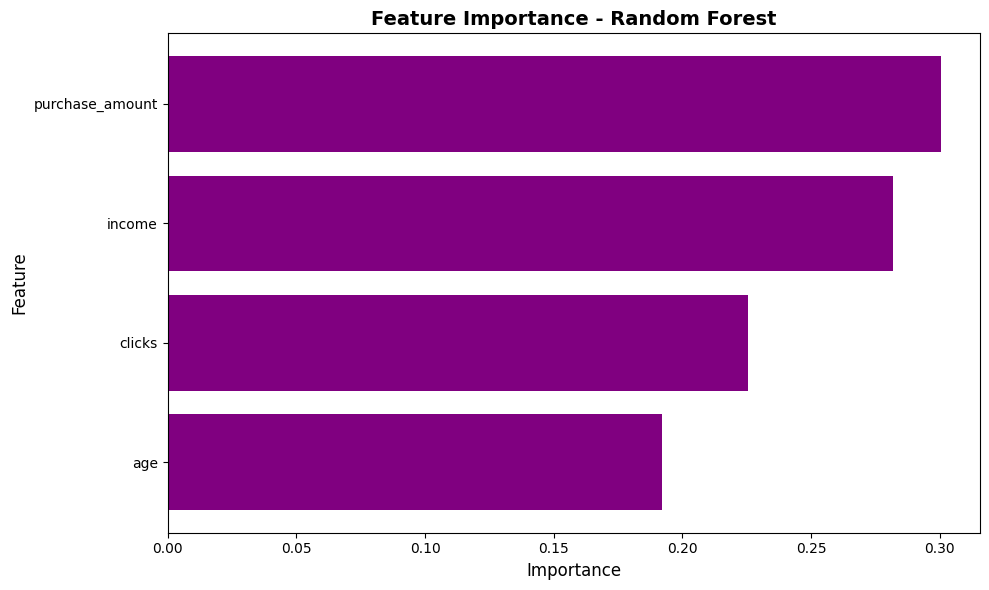

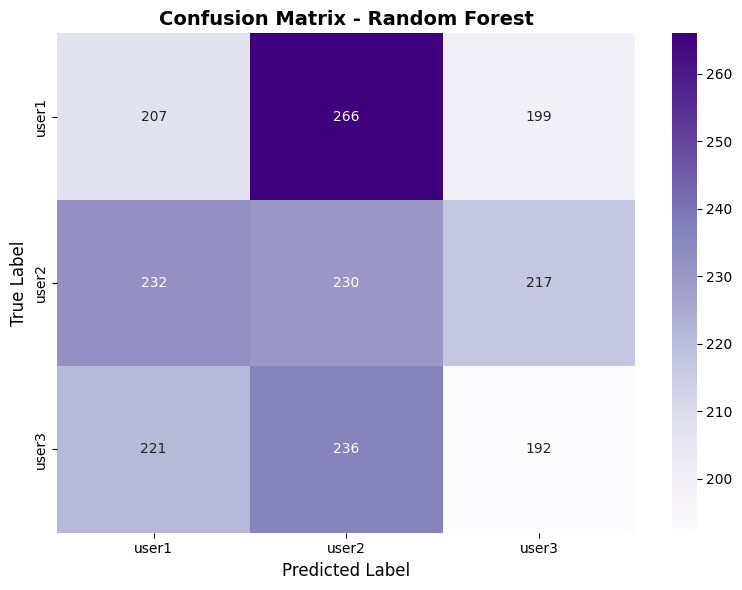

In [26]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train_encoded)

# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Calculate accuracy
train_accuracy_rf = accuracy_score(y_train_encoded, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test_encoded, y_test_pred_rf)

print("="*60)
print("RANDOM FOREST RESULTS")
print("="*60)
print(f"Training Accuracy: {train_accuracy_rf:.4f} ({train_accuracy_rf*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy_rf:.4f} ({test_accuracy_rf*100:.2f}%)")

print("\nClassification Report (Test Set):")
print(classification_report(y_test_encoded, y_test_pred_rf, 
                          target_names=label_encoder.classes_))

# Feature importance
feature_importance_rf = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance_rf)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['feature'], feature_importance_rf['importance'], color='purple')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Confusion Matrix
cm_rf = confusion_matrix(y_test_encoded, y_test_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach
